# Notebook For Figure 5

### TODOs

- [ ] Clean/Structure this notebook with the same organization as Figure 1 (describe function panels by panels).  


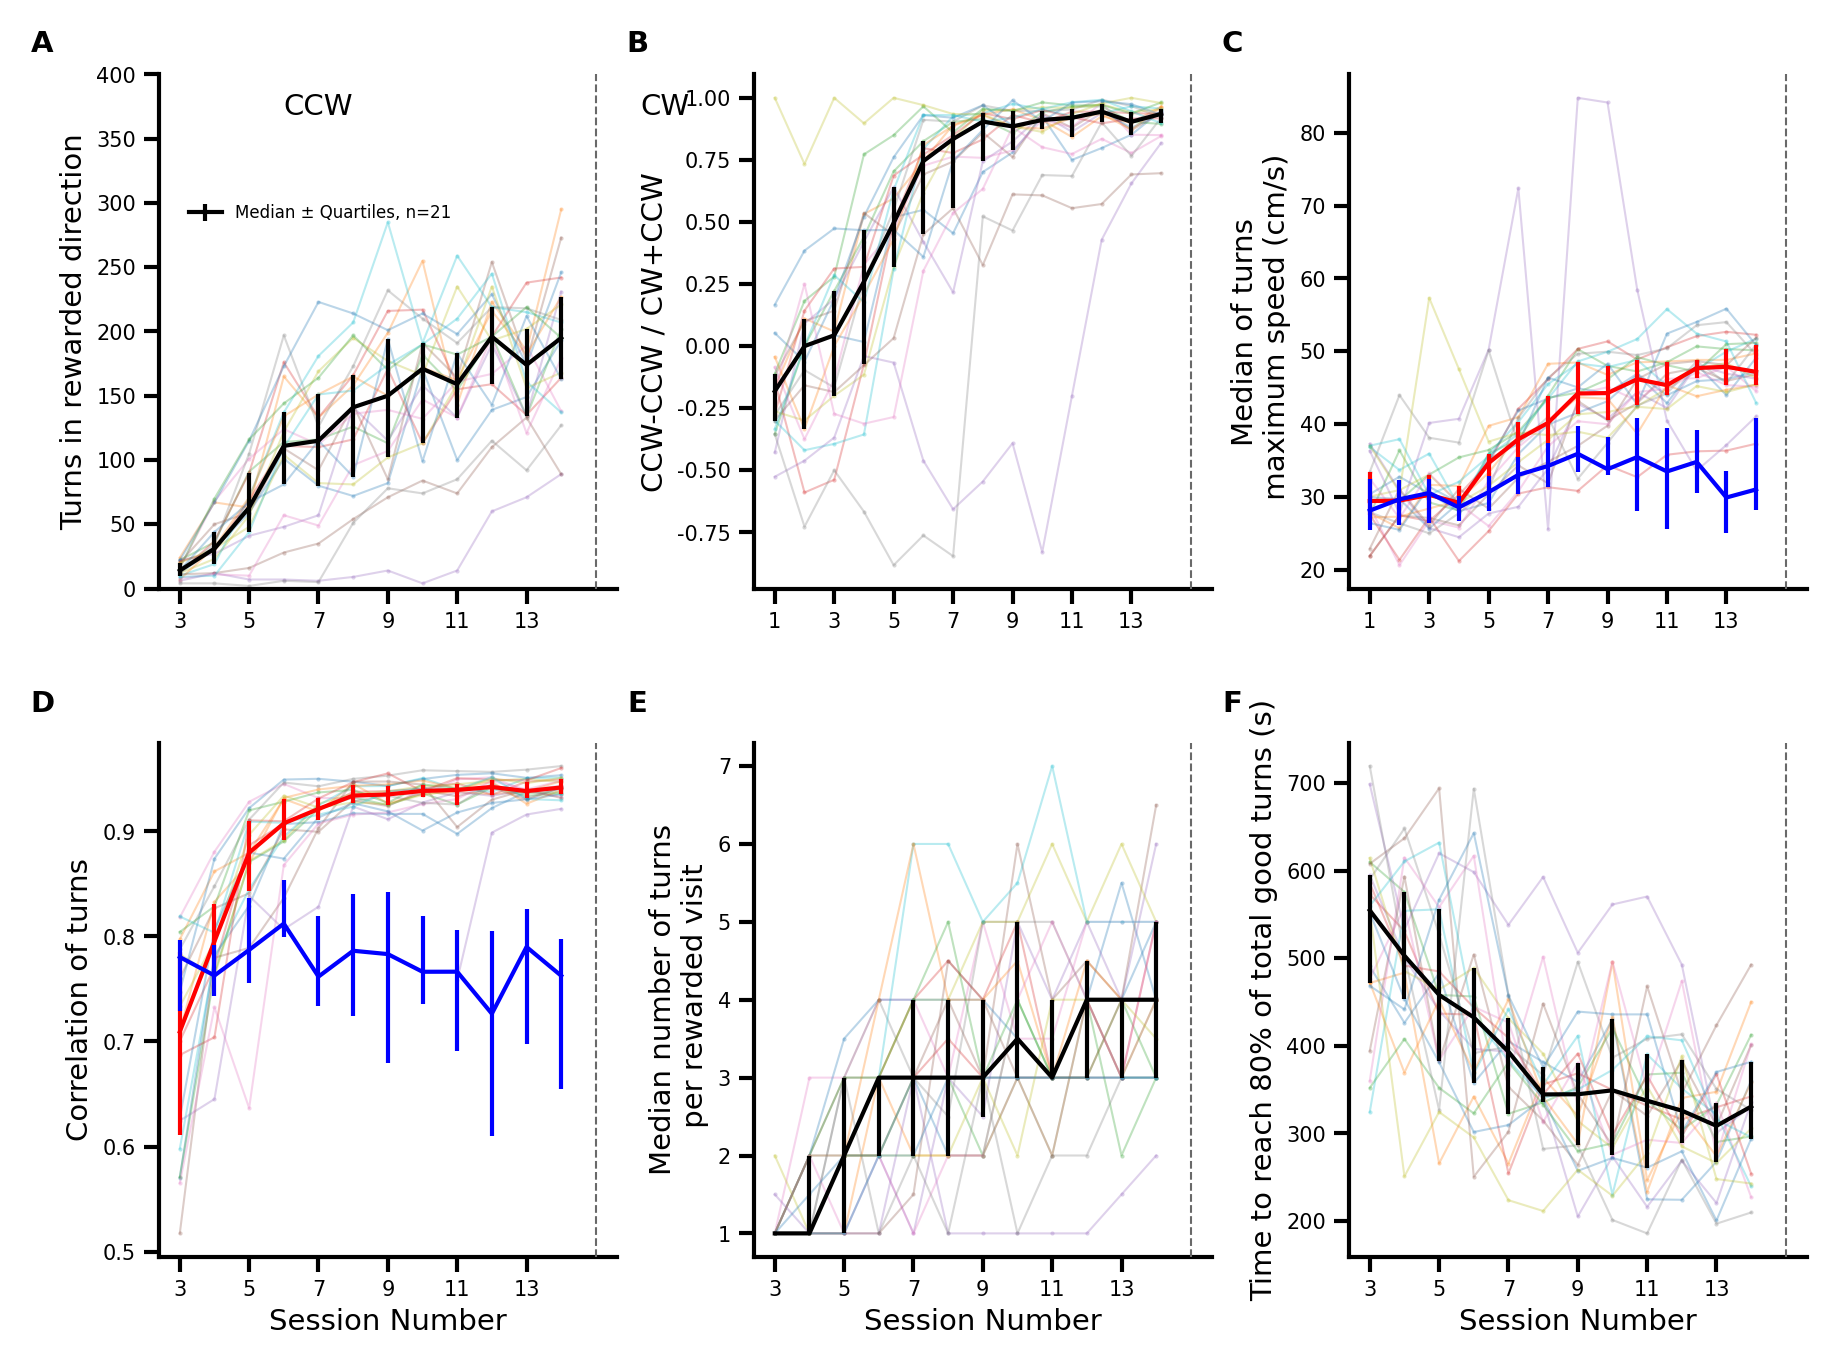

In [130]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("Figure3.png")
display(img)


# 1. Imports necessary libraries and functions

In [131]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
import numpy as np
import pickle

plt.style.use('paper.mplstyle')




# 2. Select mice to analyse
### Define the data_folder where your MOU* folders are, generate a list of MOU* folders and for each mouse generate a list of all the sessions recorded

In [132]:
# Finding and importing data

# path_to_data_folder is the path of the folder where you store the folders of your different mice.


path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/AurelienData/'
#path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'

# Analysing the entire group of mice
mice_to_analyse = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_14",
    "MOUB6NN_2", "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_9", "MOUB6NN_11", "MOUB6NN_13", "MOUB6NN_15"
]

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')



All mice folders are present in data folder.
 21 mice will be analysed



# 3. Select the last session to be analysed and the mice that will be highlighted in the plots.

In [133]:
# Chose the number of the last session to plot
#session_limit = 20

# TODO session_limit is obsolete

start_session_index = 0 # first session
end_session_index = 20 # this session is not included 


# TODO comment if the last index is included. 

# Chose mice that will be used as examples
mice_to_compare = ['','']#['MOUEml1_8', 'MOUB6NN_9']


# 4. Definition of functions

### General functions

In [134]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

In [135]:
def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index, start_session_index=0):
    
    """
    Determines the rewarded direction for the last session of a given mouse.
    In the protocol this notebook is used for, the rewarded direction of the 
    last session is the same as in all the sessions where rewarding is allowed. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction
        start_session_index (int): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list 

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:]

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[start_session_index+session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
            
        else:
            print('ERROR: Unexpected unique rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction

In [136]:
def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], show_individual_mice=True,
                         median_color='black',session_limit=[None,None], show_xlabel=True, ylabel='', 
                         tick_interval=1, xlim=None, ylim=None, show_legend=True):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        session_limit (tuple, optional): Inrerval of session indexes to plot. Defaults to [None,None] (plot all sessions).
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis. Defaults to 'Distance Ran'.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    # Loop through each mouse and gather session data
    for mouse in mice_list:
        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse][session_limit[0]:session_limit[1]]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:
    
            if mouse in mice_to_highlight: # Plot the values in opac dark orange or green if the current mouse is in mice_to_highlight
                highlight_colors = ["darkorange", "green"]
                color_idx = mice_to_highlight.index(mouse) if mice_to_highlight.index(mouse) < len(highlight_colors) else 0
                ax.plot(session_indices, values, color=highlight_colors[color_idx], marker='o', linewidth=0.5, 
                        markersize=1, label=f"Mouse {mice_to_highlight.index(mouse) + 1}", zorder=100*len(median_color))
            else:
                ax.plot(session_indices, values, marker='o', linewidth=0.5, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(sorted_sessions, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 1, label=f'Median \u00B1 Quartiles, n={len(mice_list)}', zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1, max_index + 1, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:
        ax.legend(frameon=False, fontsize=4, loc=(0.05, 0.7))


### Functions to compute the correlation of trajectories.

In [137]:
def towers_coordinates_as_dictionnary(towers_coordinates_cm):
    
    """
    Converts a dictionary of tower coordinates into a structured dictionary 
    where each tower's coordinates are labeled with explicit corner names.

    Arguments:
        towers_coordinates_cm (dict): Dictionary where keys are tower names and 
                                      values are lists/tuples of four coordinates.

    Returns:
        dict: A dictionary mapping tower names to their respective coordinates, 
              labeled as 'NW' (North-West), 'NE' (North-East), 'SE' (South-East), 
              and 'SW' (South-West).
    """

    # Initialize a dictionary to store labeled coordinates
    towers_coordinates_as_dict = {}

    # Predefined corner names in the order expected from input coordinates
    corner_names = ['NW', 'NE', 'SE', 'SW']

    # Map each tower's coordinates to its corresponding corner names
    for tower, coordinates in towers_coordinates_cm.items():
        towers_coordinates_as_dict[tower] = {
            corner_names[i]: coord for i, coord in enumerate(coordinates)
        }

    return towers_coordinates_as_dict


In [138]:
def get_tower_and_corner(run_around_tower):

    """
    Get the label of the tower and corner around wich the run around tower is happened
    based on the second and third elements saved in run_around_tower: 'N' for north, 'S' for south, 'E' for east, 'W' for west.
    
    Argument:
        run_around_tower (list): a list containing information about a run around tower

    Returns:
        str: Name of the tower around which the run occured
        str: A two character string. The first character is the name of the starting trapeze,
             the last character is the name of the ending trapeze  
    """
    
    # Extract tower name, starting name and ending trapeze name 
    tower_name = run_around_tower[1][0]
    start_trapeze = run_around_tower[1][1]
    end_trapeze = run_around_tower[2][1]
    
    # Determine the corner based on the start and end faces
    if start_trapeze == 'W' and end_trapeze == 'S':
        corner = 'SW'
    elif start_trapeze == 'S' and end_trapeze == 'E':
        corner = 'SE'
    elif start_trapeze == 'E' and end_trapeze == 'N':
        corner = 'NE'
    elif start_trapeze == 'N' and end_trapeze == 'W':
        corner = 'NW'
    elif start_trapeze == 'W' and end_trapeze == 'N':
        corner = 'NW'
    elif start_trapeze == 'N' and end_trapeze == 'E':
        corner = 'NE'
    elif start_trapeze == 'E' and end_trapeze == 'S':
        corner = 'SE'
    elif start_trapeze == 'S' and end_trapeze == 'W':
        corner = 'SW'
    else:
        corner = None  # Handle unexpected cases
    
    return tower_name, corner

In [139]:
def rotate_SWtrajectory_90_ccw(trajectory):
    
    """
    Rotates the input trajectory of 90° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 90° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, -1], [1, 0]])
    
    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory


In [140]:
def rotate_NWtrajectory_180_ccw(trajectory):

    """
    Rotates the input trajectory of 180° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 180° counter-clockwise

    """

    return -trajectory


In [141]:
def rotate_NEtrajectory_270_ccw(trajectory):
    
    """
    Rotates the input trajectory of 270° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 270° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, 1], [-1, 0]])

    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory


In [142]:
def resample_trajectory(trajectory, target_size):
    """
    Resample a single trajectory to have the decided number of points number of points.
    
    Arguments:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).
        target_size (int): The target number of points (X).
        
    Returns:
        numpy.ndarray: A 2D numpy.ndarray of shape (2, target_size).
    """

    # Get current number of trajectory points
    current_size = trajectory.shape[1]
    
    # Create an array of indices for the original trajectory points and the decided trajectory points
    original_indices = np.linspace(0, current_size - 1, num=current_size)
    target_indices = np.linspace(0, current_size - 1, num=target_size)
    
    # Resample by interpolating the trajectory for each row (x and y coordinates)
    resampled_trajectory = np.array([np.interp(target_indices, original_indices, trajectory[i, :])
                                     for i in range(2)])
    
    return resampled_trajectory



In [143]:
def resample_all_trajectories(all_trajectories, target_number_of_points):
    
    """
    Resample all trajectories to have the same decided number of points.
    
    Arguments:
        all_trajectories (list): A list of 2D numpy.ndarray of shape (2, X).
        target_number_of_points (int): The decided number of points for each trajectory.
        
    Returns:
        list: A list of resampled 2D numpy.ndarray of shape (2, target_number_of_points).
    """
    # Resample the all the trajectories in all_trajectories and store them in resampled_trajectories
    resampled_trajectories = [resample_trajectory(trajectory, target_number_of_points) for trajectory in all_trajectories]
    
    return resampled_trajectories


In [144]:
def compute_pairwise_correlations(trajectories):
    
    """
    Compute the Pearson correlation coefficients of each pair of flattened trajectories 
    (i.e correlation of the concatenation of x values and y values of pairs of trajectories) in a list.

    Arguments:
        trajectories (list of numpy.ndarray of shape (2, X)): A list where each element is a numpy.ndarray 
                                           representing a trajectory.

    Returns:
        list of float: A list of correlation coefficients between all unique pairs of trajectories.
    """

    num_trajectories = len(trajectories)
    print(f"Number of trajectories: {num_trajectories}")

    correlations = []

    # Iterate over all unique trajectory pairs
    for i in range(num_trajectories):
        for j in range(i + 1, num_trajectories):
            
            traj1 = trajectories[i]
            traj2 = trajectories[j]
            
            # Flatten trajectories for correlation computation
            traj1_flat = traj1.flatten()
            traj2_flat = traj2.flatten()
            
            # Compute Pearson correlation coefficient
            corr = np.corrcoef(traj1_flat, traj2_flat)[0, 1]
            correlations.append(corr)

    return correlations


### Functions to compute the time to reach 80% of the number of turns in rewarded direction

In [145]:
def accumulation_threshold(cummulated_events_time, threshold_fraction=0.8):

    """
    Compute the first time point at which the cummulated number of event in cummulated_events_time
    is above a threshold, that is a fraction (80% by default) of the total number of events.
    
    Arguments:
        cummulated_events_time (list): list of time at which one event occurs.
        threshold_fraction (float, optional): fraction of the total number of event that will used as threshold. 

    Returns:
        float: first value in cummulated_events_time that is above the
        
    """

    # Compute the total number of events
    total_events = len(cummulated_events_time)

    # Initialise index of the first event
    i = 0

    # Compute the fraction of cummulated events
    fraction_of_events = (i+1)/total_events

    # Iterate while the fraction of cummulated events is lower than the threshold fraction 
    while fraction_of_events<threshold_fraction:

        # Increase the index
        i = i + 1
        # Update the fraction of cummulated events at the new index
        fraction_of_events = (i+1)/total_events

    # Return the first time in cummulated_events_time at which the fraction of cummulated events is higher than threshold_fraction.  
    return cummulated_events_time[i]

In [146]:
def cumulated_turns_time_profile(folder_path_mouse_to_process, session_to_process, rewarded_direction):
    """
    Computes the cumulative number of runs around a tower at each time a new run around a tower occurs, for a given session and a given mouse.

    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse session data.
        session_to_process (str): Name of the session to be processed.
        reference_session_index (int): Index of the session that will be used to define the rewarded direction
        
    Returns:
        tuple: Two lists containing:
            - (good_turns_time, cumulated_good_turns): Sorted times and cumulative counts for turns in rewarding direction.
            - (bad_turns_time, cumulated_bad_turns): Sorted times and cumulative counts for turns in non-rewarded direction.
    """

    # Construct the path to the session pickle file
    output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

    # Load session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Deep copy the list of turn epochs
    runs_around_tower = copy.deepcopy(session_data['all_epochs']['run_around_tower'])

    # Initialize lists to store filtered turns
    time_of_runsaroundtower_CW = []
    time_of_runsaroundtower_CCW = []

    # Iterate through each recorded turn around the tower
    for run_around_tower in runs_around_tower:

        # Categorize turns based on direction
        if run_around_tower[3]['direction'] == 'CW':
            time_of_runsaroundtower_CW.append(run_around_tower[4]['epoch_time'])
        elif run_around_tower[3]['direction'] == 'CCW':
            time_of_runsaroundtower_CCW.append(run_around_tower[4]['epoch_time'])

    # Sort the turn times for cumulative calculations
    CW_times_sorted = np.sort(time_of_runsaroundtower_CW)
    CCW_times_sorted = np.sort(time_of_runsaroundtower_CCW)

    # Compute cumulative counts for each direction
    CW_cumulative = np.arange(1, len(CW_times_sorted) + 1)
    CCW_cumulative = np.arange(1, len(CCW_times_sorted) + 1)
    
    # Assign good and bad turns based on the rewarded direction
    if rewarded_direction == 'CW':
        good_turns_time = CW_times_sorted
        bad_turns_time = CCW_times_sorted
        cumulated_good_turns = CW_cumulative
        cumulated_bad_turns = CCW_cumulative

    elif rewarded_direction == 'CCW':
        good_turns_time = CCW_times_sorted
        bad_turns_time = CW_times_sorted
        cumulated_good_turns = CCW_cumulative
        cumulated_bad_turns = CW_cumulative

    elif rewarded_direction == 'X':

        good_turns_time = np.ones(len(CCW_times_sorted))*np.nan
        bad_turns_time = np.ones(len(CW_times_sorted))*np.nan
        cumulated_good_turns = np.ones(len(CCW_cumulative))*np.nan
        cumulated_bad_turns = np.ones(len(CW_cumulative))*np.nan

    else:
        print('ERROR: Unexpected rewarded direction value')
        return None  # Explicitly return None to indicate an error

    return [good_turns_time, cumulated_good_turns], [bad_turns_time, cumulated_bad_turns]


### Functions to compute the median number of turns per visits where at least one reward has been delivered

In [147]:
def order_runs(all_epochs):

    """
    Sort epochs in chronological order, omitting immobility epochs.

    Arguments:
        all_epoch (dict): dictionnary containing all the epochs, sorted by type of epoch. Each key is a different type of epoch.

    Returns:
        list: ordered_all_runs containing all the epochs omitting immobility epochs, sorted in chronological way.
        list: ordered_all_runs_frames containing all the epoch's frame intervals, omitting immobility epochs, sorted in chronological way.

    """

    # Initialize empty lists to store ordered runs and their first frames
    ordered_all_runs = []
    ordered_all_runs_frames = []

    # Loop through each key in the all_epochs dictionary
    for k in all_epochs.keys():
        # Skip the 'immobility' key
        if k != 'immobility':
            # Loop through each run in the current key's list
            for i in range(len(all_epochs[k])):
                # Add the current run to ordered_all_runs
                ordered_all_runs.append(all_epochs[k][i])
                # Add the first frame of the current run to ordered_all_runs_frames
                ordered_all_runs_frames.append(all_epochs[k][i][0])

    # Sort the frames list based on the first element of each frame
    ordered_all_runs_frames = sorted(ordered_all_runs_frames, key=lambda x: x[0])
    
    # Sort the runs list based on the first element of each run
    ordered_all_runs = sorted(ordered_all_runs, key=lambda x: x[0])

    # Return the ordered lists of runs and their first frames
    return ordered_all_runs, ordered_all_runs_frames


In [148]:
def define_visit(all_epochs):
    """
    Determines the number of turns, rewarded turns, and maximum rewards for each visit.
    A visit is defined as the mouse entering one of the trapeze of a tower and doing 
    at least one run around tower before leaving the trapezes of the tower.

    Arguments:
        all_epochs (dict): A dictionary containing data for all epochs

    Returns:
        list: A list of dictionaries, each representing a visit with details about turns, rewarded turns,
              maximum rewards, patch, and visit time.
    """

    visits = []  # List to store information about each visit
    n = -1  # Index to keep track of the current visit

    # Extract runs around the tower from the input data
    runs_around_tower = all_epochs['run_around_tower']

    # Order the runs and their corresponding frames
    ordered_all_runs, ordered_all_runs_frames = order_runs(all_epochs)

    # Iterate through each run around the tower
    for run_around_tower in runs_around_tower:
        # Determine if the turn is rewarded and the maximum rewards for the run
        is_good_turn = run_around_tower[3]['Rewarded']
        max_rewards = run_around_tower[3]['max_rewards']

        # Find the index of the current run in the ordered list of runs frame intervals
        ordered_idx = ordered_all_runs_frames.index(run_around_tower[0])

        # Determine the departure and arrival of the previous run
        departure, arrival = [ordered_all_runs[ordered_idx-1][1][0], ordered_all_runs[ordered_idx-1][2][0]] if ordered_idx != 0 else ['', '']

        # Check if the previous run was not a turn or if this is the first visit
        is_previous_run_not_a_turn = (departure != arrival) or len(visits) == 0

        if is_previous_run_not_a_turn:
            # Start a new visit
            n += 1
            visits.append({})

            # Initialize the visit details
            visits[n]['turns'] = 1
            visits[n]['rewarded_turns'] = int(is_good_turn)
            visits[n]['max_reward'] = max_rewards
            visits[n]['patch'] = run_around_tower[1][0]
            # The beginning of the visit is set when the first run around tower of the visit starts
            visits[n]['visit_time'] = run_around_tower[4]['epoch_time'] 
        else:
            # Update the current visit with the new turn information
            visits[n]['rewarded_turns'] += int(is_good_turn)
            visits[n]['turns'] += 1

    return visits


In [149]:
def compute_turns_per_visit_by_reward(folder_path_mouse_to_analyse, session_to_analyse):
    """
    Computes the number of turns, rewarded turns, visit starting time, and maximum rewards for each visit
    for a given session of a given mouse, sorted in chronological order of the visits occurence.

    Arguments:
        folder_path_mouse_to_analyse (str): The path to the folder containing the mouse data.
        session_to_analyse (str): The session to analyze.

    Returns:
    list: A list containing numpy arrays of turns per visit, rewarded turns per visit, visit times,
          and maximum rewards.
    """

    # Construct the output pickle file path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Load the pickle file containing session data
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Define the visits using the define_visit function
    visit = define_visit(session_data['all_epochs'])

    # Print the number of visits
    print(len(visit), 'number of visits')

    # Initialize lists to store the results
    turns_per_visit = []
    rewarded_turns_per_visit = []
    visits_time = []
    max_rewards = []

    # Iterate through each visit and extract the relevant information
    for i in range(len(visit)):

        nb_of_turns = visit[i]['turns']
        nb_of_rewarded_turns = visit[i]['rewarded_turns']
        visit_time = visit[i]['visit_time']
        max_reward = visit[i]['max_reward']

        # Append the extracted information to the respective lists
        turns_per_visit.append(nb_of_turns)
        rewarded_turns_per_visit.append(nb_of_rewarded_turns)
        visits_time.append(visit_time)
        max_rewards.append(max_reward)

    # Return the results as a list of numpy.ndarray
    return [np.array(turns_per_visit), np.array(rewarded_turns_per_visit), np.array(visits_time), np.array(max_rewards)]


In [150]:
#assert False, "Stopping execution here." 

# 5. Computations

### This cell computes and store metrics that will be plotted for each mouse across sessions. Those metrics are:
    - The number of turns in rewarding direction
    - The ratio of the number of turns in rewarding direction with respect to the total number of turns
    - The median of the turns in rewarded direction maximum speed
    - The median of the Pearson correlation coefficients of each pair of flattened trajectories (i.e correlation of the concatenation of x values and y values of pairs of trajectories).
    - The median number of turns per visits where at least one reward has been delivered.
    - The time that the mouse took to perform 80% of the total number of turns in rewarded direction of the session. 

In [151]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_median_maximum_CW_turn_speed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_maximum_CCW_turn_speed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_flexi_ratio_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_total_goodturns_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_total_rewardedturns_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_turns_per_rewarded_visit = {mouse: [] for mouse in mice_to_analyse}
mouse_goodturns_threshold_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[start_session_index:end_session_index]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')


    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        
    
        # Determine the rewarded direction for all sessions of the current mouse
        rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index)
        

        # Load session data
        session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, session_to_process)

        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run around tower results from the session data
        run_around_tower_sessionresult = session_data['run_around_tower_sessionresult']
        TotalTurns = run_around_tower_sessionresult['All']['total_CCW'] + run_around_tower_sessionresult['All']['total_CW']
        flexi_ratio = (run_around_tower_sessionresult['All']['total_CCW'] - run_around_tower_sessionresult['All']['total_CW'])/(TotalTurns)
        TotalRewardedTurns = run_around_tower_sessionresult['All']['rewarded_CCW'] + run_around_tower_sessionresult['All']['rewarded_CW']

        # Determine the number of good turns based on the rewarded direction
        if rewarded_direction == 'CW':
            good_turns = run_around_tower_sessionresult['All']['total_CW']
        elif rewarded_direction == 'CCW':
            good_turns = run_around_tower_sessionresult['All']['total_CCW']
        elif rewarded_direction == 'X':
            good_turns = np.nan
        else:
            good_turns = run_around_tower_sessionresult['All']['total_CW'] + run_around_tower_sessionresult['All']['total_CCW']

        # Initialize lists to store turn speeds
        CW_turns_max_speed = []
        CCW_turns_max_speed = []

        # Iterate through each run around the tower
        for n in range(len(session_data["all_epochs"]["run_around_tower"])):
            run = session_data["all_epochs"]["run_around_tower"][n]

            # Append turn speeds in the corresponding direction's dictionnary
            if run[3]['direction'] == 'CW':
                CW_turns_max_speed.append(run[4]["epoch_maxspeed"])

            if run[3]['direction'] == 'CCW':
                CCW_turns_max_speed.append(run[4]["epoch_maxspeed"])


        # If reward delivery is not allowed, set to numpy.nan the metrics values concerning rewarded direction
        if rewarded_direction == 'X':
            
            mouse_median_maximum_CW_turn_speed_persession[mouse].append([session_index + 1, np.median(CW_turns_max_speed)])
            mouse_median_maximum_CCW_turn_speed_persession[mouse].append([session_index + 1, np.median(CCW_turns_max_speed)])
            mouse_flexi_ratio_persession[mouse].append([session_index + 1, flexi_ratio])
            mouse_total_goodturns_persession[mouse].append([session_index + 1, np.nan])
            mouse_total_rewardedturns_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_turns_per_rewarded_visit[mouse].append([session_index + 1, np.nan])
            mouse_goodturns_threshold_persession[mouse].append([session_index + 1, np.nan])

            continue        

        # Compute cumulated turns time profiles, for turns in rewarded and unrewarded direction
        [good_turns_time, cumulated_good_turns], [bad_turns_time, cumulated_bad_turns] = cumulated_turns_time_profile(folder_path_mouse_to_process, session_to_process, rewarded_direction)

        # Determine the good turns threshold time
        good_turns_threshold_time = accumulation_threshold(good_turns_time)

        # Compute turns per visit by reward
        turns_per_visit, rewarded_turns_per_visit, visits_time, max_rewards = compute_turns_per_visit_by_reward(folder_path_mouse_to_process, session_to_process)
        unrewarded_turns_per_visit = turns_per_visit - rewarded_turns_per_visit

        # Compute turns per rewarded and unrewarded visits
        turns_per_rewarded_visit = np.where(np.logical_not(np.equal(rewarded_turns_per_visit, 0)), turns_per_visit, np.nan)
        turns_per_unrewarded_visit = np.where(np.logical_not(np.equal(unrewarded_turns_per_visit, 0)), turns_per_visit, np.nan)

        # Append session data to the respective dictionaries
        mouse_median_maximum_CW_turn_speed_persession[mouse].append([session_index + 1, np.median(CW_turns_max_speed)])
        mouse_median_maximum_CCW_turn_speed_persession[mouse].append([session_index + 1, np.median(CCW_turns_max_speed)])
        mouse_flexi_ratio_persession[mouse].append([session_index + 1, flexi_ratio])
        mouse_total_goodturns_persession[mouse].append([session_index + 1, good_turns])
        mouse_total_rewardedturns_persession[mouse].append([session_index + 1, TotalRewardedTurns]) #
        mouse_median_turns_per_rewarded_visit[mouse].append([session_index + 1, np.nanmedian(turns_per_rewarded_visit)])
        mouse_goodturns_threshold_persession[mouse].append([session_index + 1, good_turns_threshold_time])


Mouse MOUEml1_5. There is/are 20 sessions:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615', 'MOUEml1_5_20230428-1044', 'MOUEml1_5_20230428-1628', 'MOUEml1_5_20230429-1018', 'MOUEml1_5_20230429-1524', 'MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529'] 

18 number of visits
33 number of visits
33 number of visits
45 number of visits
44 number of visits
42 number of visits
36 number of visits
62 number of visits
50 number of visits
43 number of visits
36 number of visits
57 number of visits
70 number of visits
66 number of visits
39 number of visits
58 number of visits
55 number of visits
47 number of visits
Mouse MOUEml1_8. There is/are 20 sessions:
['MOUEml1_8

/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/d

13 number of visits
22 number of visits
19 number of visits
36 number of visits
28 number of visits
33 number of visits
37 number of visits
41 number of visits
46 number of visits
58 number of visits
35 number of visits


/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


42 number of visits
90 number of visits
57 number of visits
55 number of visits
53 number of visits
47 number of visits
39 number of visits
Mouse MOUB6NN_13. There is/are 20 sessions:
['MOUB6NN_13_20241122-1135', 'MOUB6NN_13_20241122-1641', 'MOUB6NN_13_20241123-1225', 'MOUB6NN_13_20241123-1705', 'MOUB6NN_13_20241124-1229', 'MOUB6NN_13_20241124-1740', 'MOUB6NN_13_20241125-1122', 'MOUB6NN_13_20241125-1632', 'MOUB6NN_13_20241126-1124', 'MOUB6NN_13_20241126-1629', 'MOUB6NN_13_20241127-1147', 'MOUB6NN_13_20241127-1645', 'MOUB6NN_13_20241128-1158', 'MOUB6NN_13_20241128-1715', 'MOUB6NN_13_20241129-1207', 'MOUB6NN_13_20241129-1647', 'MOUB6NN_13_20241130-1214', 'MOUB6NN_13_20241130-1650', 'MOUB6NN_13_20241201-1209', 'MOUB6NN_13_20241201-1656'] 

11 number of visits
14 number of visits
37 number of visits
58 number of visits
56 number of visits
55 number of visits
55 number of visits
59 number of visits
74 number of visits
74 number of visits
62 number of visits
52 number of visits
94 number of 

### This cell process the runs around tower trajectory such that:
    - All runs around tower with the same starting and ending trapeze and are shifted to have the same origin, independently of the tower where they occur.
    - All runs around tower are rotated from 90°/180°/270° counter-clockwise when the corner around which the mouse turns is South-West/North-West/North-East.
    - Does so separately for turns in clockwise and counter-clockwise direction.

In [152]:
overwritte_previous_correlations=False # we save the trajectory correlations for each session, 
                                        #if True, we overwrite the previous correlations, 
                                        # if False we don't run the correlations analysis


# Initialize a dictionary to store all trajectories for each mouse, with empty lists for each session
mouse_alltrajectories_persession = {mouse: {} for mouse in mice_to_analyse}

# Initialize a dictionary to store realigned and rotated trajectories for each mouse, with empty dictionaries for each session
trajectories_per_session_realigned_rotated = {mouse: {} for mouse in mice_to_analyse}

# Loop through each mouse in the list of mice to realign all their turns trajectory
for mouse in mice_to_analyse:
    # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:end_session_index]

    # Get the number of sessions to process
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Loop through each session for the current mouse to realign all the turns trajectory from those sessions
    for session_index, session_to_process in enumerate(sessions_to_process):
        print(f'Getting the run trajectory of session {session_index}')

        # Define the path to the pickle file for the current session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

          # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            continue

        # check if correlations pickle file already exist

        # Define the pickle filename to save the realigned and rotated trajectories for this session
        overall_trajectory_correlations_per_session_pickle_filename = (
            f"{session_to_process}_overall_trajectory_correlations_per_session.pickle"
        )
        overall_trajectory_correlations_per_session_pickle_filepath = os.path.join(
            folder_path_mouse_to_process, session_to_process, overall_trajectory_correlations_per_session_pickle_filename
        )

        if not os.path.exists(overall_trajectory_correlations_per_session_pickle_filepath) or overwritte_previous_correlations:
        
            # Load the data from the pickle file
            with open(output_pickle_filepath, 'rb') as file:
                session_data = pickle.load(file)

            # Initialize entries for the current session in the dictionaries
            mouse_alltrajectories_persession[mouse][session_index] = []
            trajectories_per_session_realigned_rotated[mouse][session_index] = {'CW':[], 'CCW':[]}

            # Get the runs around the tower for the current session
            runs_around_tower = session_data['all_epochs']['run_around_tower']
            # Get the trajectory of the mouse
            positions = np.array(session_data['positions'])

            # Get the tower coordinates and convert them to a dictionary format
            towers_coordinates_cm = session_data['towers_coordinates_cm']
            towers_coordinates_as_dict = towers_coordinates_as_dictionnary(towers_coordinates_cm)

            # Loop through each run around the tower to realign them
            for run_around_tower in runs_around_tower:
                # Only process runs around tower where there was only one trapeze switch 
                if run_around_tower[3]['num_trapezeswitch'] == 1:
                    # Extract the run trajectory
                    run_trajectory = positions[:, run_around_tower[0][0]:run_around_tower[0][1]]
                    mouse_alltrajectories_persession[mouse][session_index].append(run_trajectory)

                    # Get the tower and corner names
                    tower_name, corner = get_tower_and_corner(run_around_tower)

                    # Access tower and corner coordinates from the dictionary
                    if tower_name in towers_coordinates_as_dict and corner in towers_coordinates_as_dict[tower_name]:
                        this_corner_coordinates = towers_coordinates_as_dict[tower_name][corner]
                    else:
                        print(f"Invalid tower or corner: {tower_name}, {corner}")
                        continue

                    # Extract the trajectory slice based on the start and end time indices
                    start_idx, end_idx = run_around_tower[0]
                    this_trajectory = positions[:, start_idx:end_idx]

                    # Get the corner's reference coordinates (X and Y)
                    newXreference = this_corner_coordinates[0]
                    newYreference = this_corner_coordinates[1]

                    # Shift the trajectory to reference the new corner coordinates
                    this_trajectory[0, :] -= newXreference  # Shift X coordinates
                    this_trajectory[1, :] -= newYreference  # Shift Y coordinates

                    # Rotate the trajectory based on the corner
                    if corner == 'SW':
                        this_trajectory = rotate_SWtrajectory_90_ccw(this_trajectory)
                    elif corner == 'NW':
                        this_trajectory = rotate_NWtrajectory_180_ccw(this_trajectory)
                    elif corner == 'NE':
                        this_trajectory = rotate_NEtrajectory_270_ccw(this_trajectory)

                    # Get the direction (CW or CCW)
                    direction = run_around_tower[3]['direction']

                    # Append the transformed trajectory to the appropriate list based on direction
                    trajectories_per_session_realigned_rotated[mouse][session_index][direction].append(this_trajectory)
        else:
            print(f'Correlations pickle file already exist for session {session_to_process}, skipping .....')
            #populate the trajectories_per_session_realigned_rotated with NaN to allow for the next step to run
            # Ensure the dictionary structure exists before assignment
            for direction in ['CW', 'CCW']:
                if session_index not in trajectories_per_session_realigned_rotated[mouse]:
                    trajectories_per_session_realigned_rotated[mouse][session_index] = {}

                trajectories_per_session_realigned_rotated[mouse][session_index][direction] = np.nan
                        


                


Processing mouse MOUEml1_5. There is/are 20 sessions to process:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615', 'MOUEml1_5_20230428-1044', 'MOUEml1_5_20230428-1628', 'MOUEml1_5_20230429-1018', 'MOUEml1_5_20230429-1524', 'MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529'] 

Getting the run trajectory of session 0
Correlations pickle file already exist for session MOUEml1_5_20230420-1632, skipping .....
Getting the run trajectory of session 1
Correlations pickle file already exist for session MOUEml1_5_20230421-1033, skipping .....
Getting the run trajectory of session 2
Correlations pickle file already exist for session MOUEml1_5_20230422-1046, skipping .....

### This cell uses realigned trajectories to compute the median of their correlation. It does so in several steps:
    1. Select a direction for the and loop on all mice
    2. Computes the Pearson correlation coefficients of all the pairs of trajectory in the given direction
    3. Computes the median of those coefficients and stores it in the corresponding dictionnary, depending on whether it's a turn in the rewarded or unrewarded direction.
    4. Does the same for the other direction. 

In [153]:
#modified by david to try to save trajecotry correlations
overwritte_previous_correlations=False
# Initialize dictionaries to store overall correlations per session for each direction (CW and CCW)
overall_trajectory_correlations_per_session = {mouse: {'CW': [], 'CCW': []} for mouse in trajectories_per_session_realigned_rotated}
overall_CW_turns_correlations_per_session = {mouse: [] for mouse in trajectories_per_session_realigned_rotated}
overall_CCW_turns_correlations_per_session = {mouse: [] for mouse in trajectories_per_session_realigned_rotated}

# Define the directions to process
directions = ['CW', 'CCW']

# Loop through each mouse in the list of mice to analyze
for mouse in mice_to_analyse:

     # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)


    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:end_session_index]

     # Get the number of sessions to process for the current mouse
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Loop through each session for the current mouse
    for session_index in trajectories_per_session_realigned_rotated[mouse]:

        # Skip session the correlation is already computed
        
        # Define the pickle filename to save the realigned and rotated trajectories for this session
        session_to_process = sessions_to_process[session_index]
        overall_trajectory_correlations_per_session_pickle_filename = (
            f"{session_to_process}_overall_trajectory_correlations_per_session.pickle"
        )
        overall_trajectory_correlations_per_session_pickle_filepath = os.path.join(
            folder_path_mouse_to_process, session_to_process, overall_trajectory_correlations_per_session_pickle_filename
        )

        if not os.path.exists(overall_trajectory_correlations_per_session_pickle_filepath) or overwritte_previous_correlations:
            this_session_correlation = {'CW': None, 'CCW': None}

            # Determine the rewarded direction for all sessions of the current mouse
            rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index)
    
            # If reward delivery is not allowed, set to numpy.nan the correlations
            if rewarded_direction == 'X':
                for direction in directions:
                    overall_trajectory_correlations_per_session[mouse][direction].append([session_index + 1, np.nan])
                    this_session_correlation[direction]=np.nan
                overall_CW_turns_correlations_per_session[mouse].append([session_index + 1, np.nan])
                overall_CCW_turns_correlations_per_session[mouse].append([session_index + 1, np.nan])
                # Save the dictionary for CW and CCW trajectories
                with open(overall_trajectory_correlations_per_session_pickle_filepath, 'wb') as file:
                    pickle.dump(this_session_correlation, file)
                print(f"Saved trajectories correlations for {mouse}, session {session_to_process} at {overall_trajectory_correlations_per_session_pickle_filepath}")    


                continue
                
            print(f"Processing session index: {session_index} for direction: {direction}")
            
            # Loop through each direction (CW and CCW)
            for direction in directions:
                # Access the realigned trajectories for the current session and direction
                realigned_trajectories = trajectories_per_session_realigned_rotated[mouse][session_index][direction]

                # If there are no trajectories for the current direction, skip the session
                if not realigned_trajectories:
                    print(f"No trajectories for {direction} in session {session_index}, skipping...")
                    overall_trajectory_correlations_per_session[mouse][direction].append([session_index + 1, np.nan])
                    this_session_correlation[direction]=np.nan
                    continue

                # Compute the number of realigned trajectories
                number_of_realigned_trajectories = len(realigned_trajectories)

                # If there are fewer than 5 trajectories, skip the session
                if number_of_realigned_trajectories < 5:
                    print(f"Less than 5 trajectories for {direction} in session {session_index}, skipping...")
                    overall_trajectory_correlations_per_session[mouse][direction].append([session_index + 1, np.nan])
                    if direction=='CW':
                        this_session_correlation['CW']=np.nan
                    if direction=='CCW':
                        this_session_correlation['CCW']=np.nan
                    continue
                else:
                    # Compute the length of all trajectories
                    length_all_trajectories = [trajectory.shape[1] for trajectory in realigned_trajectories]

                    # Determine the common target length for resampling (median length of all trajectories)
                    common_length = int(np.median(length_all_trajectories))

                    # Resample the trajectories to a common length (common_length)
                    resampled_realigned_trajectories = resample_all_trajectories(realigned_trajectories, common_length)

                    # Compute Pearson correlation coefficients
                    correlations = compute_pairwise_correlations(resampled_realigned_trajectories)

                    # Compute the overall correlation (median of pairwise correlations)
                    overall_correlation = np.nanmedian(correlations)

                    # Append the overall trajectory correlation for the current direction and session
                    overall_trajectory_correlations_per_session[mouse][direction].append([session_index + 1, overall_correlation])

                    if direction=='CW':
                        this_session_correlation['CW']=overall_correlation
                    if direction=='CCW':
                        this_session_correlation['CCW']=overall_correlation

            
            # Save the dictionary for CW and CCW trajectories
            with open(overall_trajectory_correlations_per_session_pickle_filepath, 'wb') as file:
                pickle.dump(this_session_correlation, file)

            print(f"Saved trajectories correlations for {mouse}, session {session_to_process} at {overall_trajectory_correlations_per_session_pickle_filepath}")    
        else:
            with open(overall_trajectory_correlations_per_session_pickle_filepath, 'rb') as file:
                this_session_correlation = pickle.load(file)  # Preserve existing values
            
            print(f"Loaded existing correlations for {mouse}, session {session_to_process}")
            for direction in directions:
                overall_correlation=this_session_correlation[direction]
                overall_trajectory_correlations_per_session[mouse][direction].append([session_index + 1, overall_correlation])



    # Store the all the correlations and session in the corresponding direction's dictionnary
    for direction in directions:
        if direction=='CW':
            overall_CW_turns_correlations_per_session[mouse] = overall_trajectory_correlations_per_session[mouse][direction]
        if direction=='CCW':
            overall_CCW_turns_correlations_per_session[mouse] = overall_trajectory_correlations_per_session[mouse][direction]
    

    

Processing mouse MOUEml1_5. There is/are 20 sessions to process:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615', 'MOUEml1_5_20230428-1044', 'MOUEml1_5_20230428-1628', 'MOUEml1_5_20230429-1018', 'MOUEml1_5_20230429-1524', 'MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529'] 

Loaded existing correlations for MOUEml1_5, session MOUEml1_5_20230420-1632
Loaded existing correlations for MOUEml1_5, session MOUEml1_5_20230421-1033
Loaded existing correlations for MOUEml1_5, session MOUEml1_5_20230422-1046
Loaded existing correlations for MOUEml1_5, session MOUEml1_5_20230422-1648
Loaded existing correlations for MOUEml1_5, session MOUEml1_5_20230423-1051
Loaded exist

# Generate the figure 

/tmp/ipykernel_4864/2263867305.py:70: RuntimeWarning: All-NaN slice encountered
  median_values.append(np.nanmedian(session_values))
/home/david/Documents/Python/4TowersTask/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


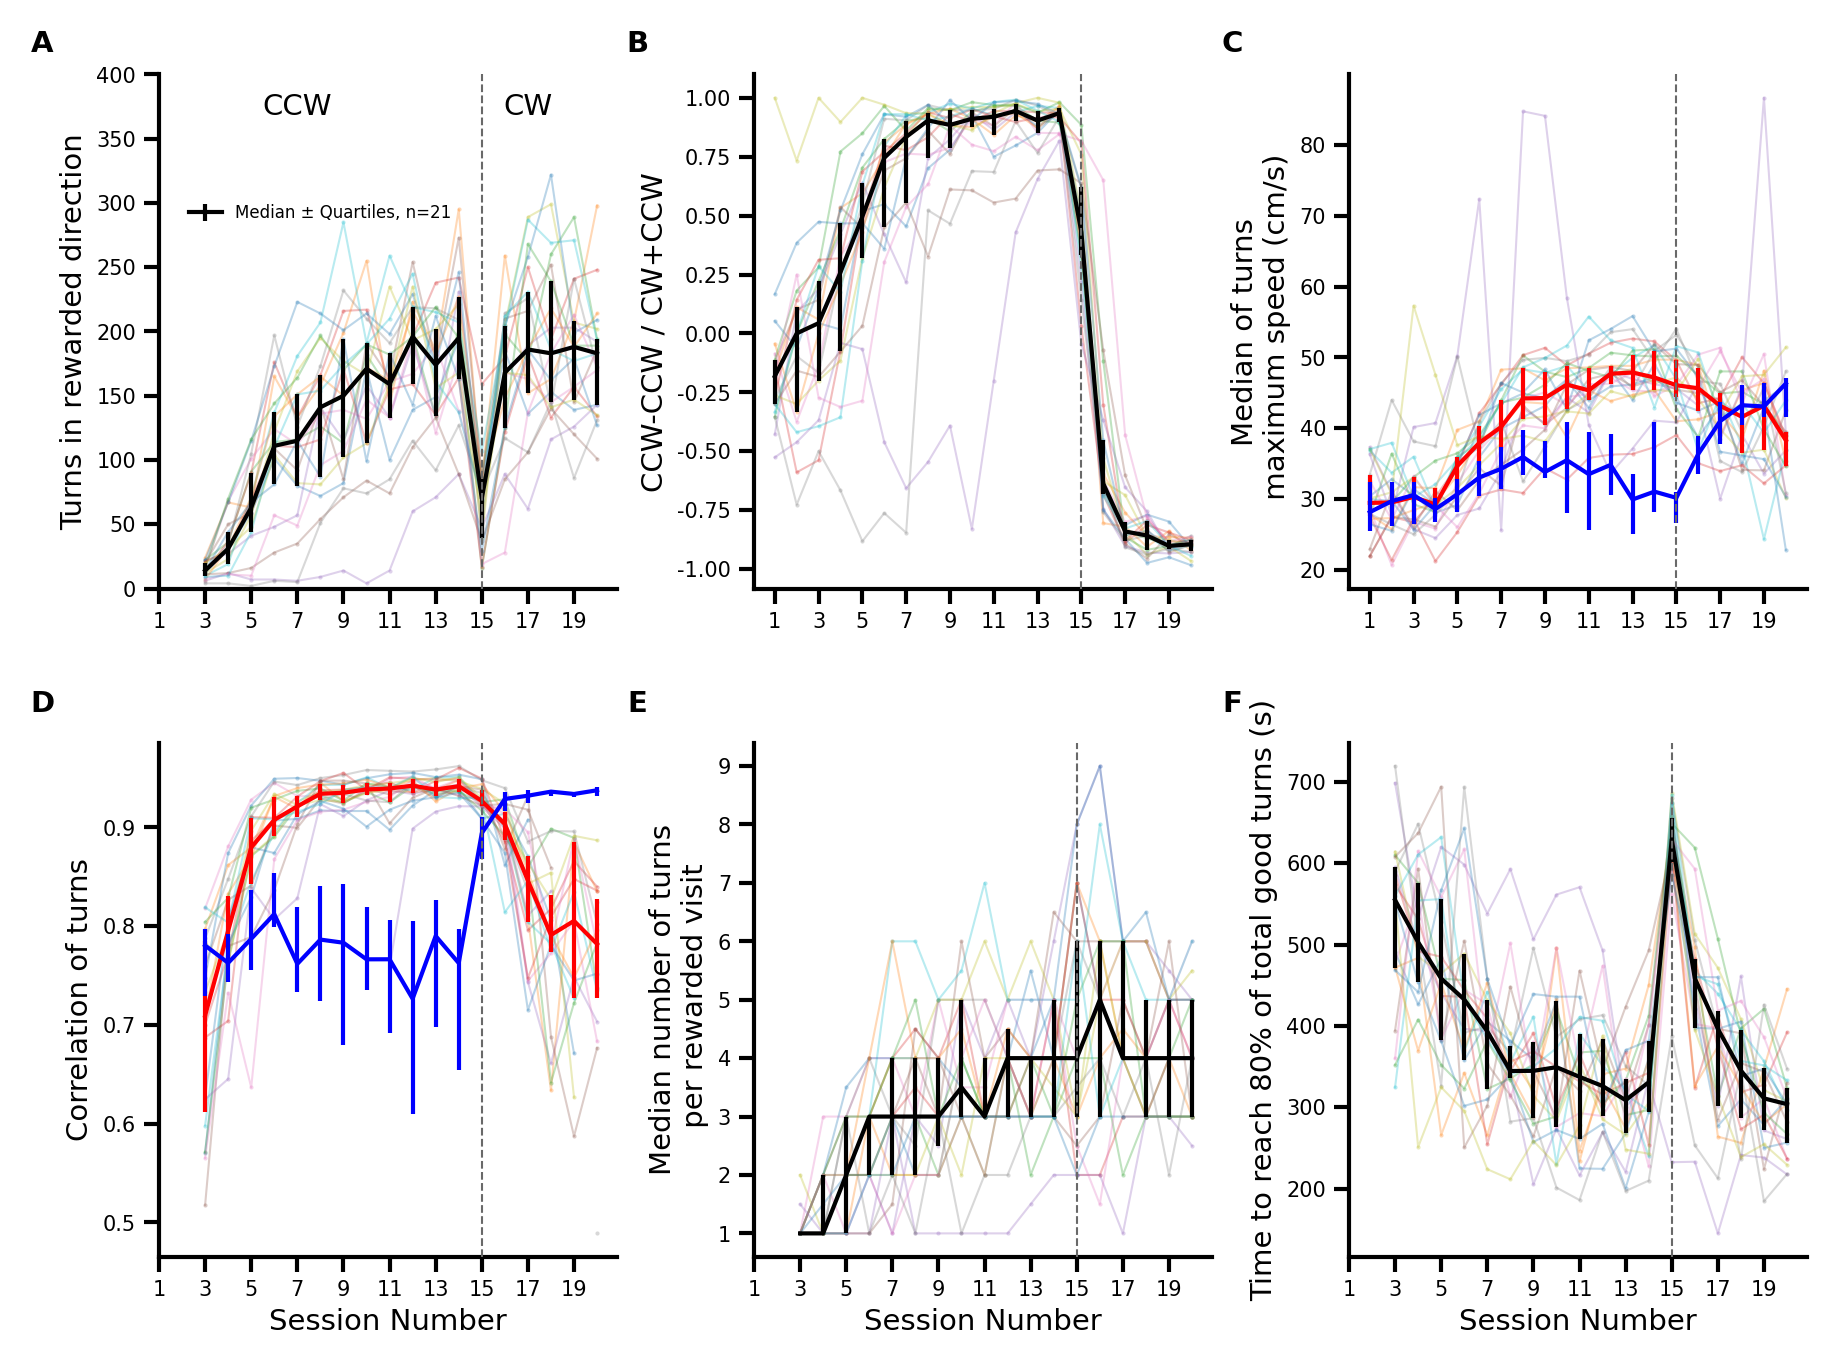

In [154]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(13)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(2, 1 , hspace=0.3, height_ratios=[1, 1])

### First row ###

row1 = gs[0].subgridspec(1, 3, wspace=.3, hspace=.3, width_ratios=[1,1,1])

ax_11 = plt.subplot(row1[0])
ax_12 = plt.subplot(row1[1])
ax_13 = plt.subplot(row1[2])

# Panel A: Turns in rewarded direction
plot_learning_curves(mouse_total_rewardedturns_persession, ax_11, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], ylim=[0,400], show_xlabel = False, ylabel='Turns in rewarded direction', tick_interval=2, )
ax_11.text(7, 375, 'CCW', va='center', ha='center', fontsize=7)
ax_11.text(17, 375, 'CW', va='center', ha='center', fontsize=7)
ax_11.axvline(x=15, zorder=1000, linestyle='--', color='dimgrey', linewidth=0.5)
fig.text(0.07, 0.9, 'A', weight='bold', va='center', ha='center', fontsize=7)
# Panel B: Turns in rewarded direction / Total turns
plot_learning_curves(mouse_flexi_ratio_persession, ax_12, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_xlabel = False, ylabel='CCW-CCW / CW+CCW', tick_interval=2, show_legend=False)
ax_12.axvline(x=15, zorder=1000, linestyle='--', color='dimgrey', linewidth=0.5)
fig.text(0.35, 0.9, 'B', weight='bold', va='center', ha='center', fontsize=7)
# Panel C: Median of turns in rewarded direction\n maximum speed
plot_learning_curves(mouse_median_maximum_CW_turn_speed_persession, ax_13, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_individual_mice=False, median_color= 'blue', show_xlabel = False, ylabel='Median of turns\n maximum speed (cm/s)', tick_interval=2, show_legend=False)
plot_learning_curves(mouse_median_maximum_CCW_turn_speed_persession, ax_13, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_individual_mice=True, median_color= 'red', show_xlabel = False, ylabel='Median of turns\n maximum speed (cm/s)', tick_interval=2, show_legend=False)
ax_13.axvline(x=15, zorder=1000, linestyle='--', color='dimgrey', linewidth=0.5)
fig.text(0.63, 0.9, 'C', weight='bold', va='center', ha='center', fontsize=7)



### Second row ###

row2 = gs[1].subgridspec(1, 3, wspace=.3, hspace=.3, width_ratios=[1,1,1])

ax_21 = plt.subplot(row2[0])
ax_22 = plt.subplot(row2[1])
ax_23 = plt.subplot(row2[2])

# Panel D: Good turns trajectory correlation
plot_learning_curves(overall_CW_turns_correlations_per_session, ax_21, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_individual_mice=False, median_color='blue', show_xlabel = True, ylabel='Correlation of turns', tick_interval=2, show_legend=False)
plot_learning_curves(overall_CCW_turns_correlations_per_session, ax_21, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_individual_mice=True, median_color='red', show_xlabel = True, ylabel='Correlation of turns', tick_interval=2, show_legend=False)
ax_21.axvline(x=15, zorder=1000, linestyle='--', color='dimgrey', linewidth=0.5)
fig.text(0.07, 0.47, 'D', weight='bold', va='center', ha='center', fontsize=7)
# Panel E: Median number of turns per rewarded visit
plot_learning_curves(mouse_median_turns_per_rewarded_visit, ax_22, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_xlabel = True, ylabel='Median number of turns\n per rewarded visit', tick_interval=2, show_legend=False)
ax_22.axvline(x=15, zorder=1000, linestyle='--', color='dimgrey', linewidth=0.5)
fig.text(0.35, 0.47, 'E', weight='bold', va='center', ha='center', fontsize=7)
# Panel F: Time to reach 80% of total good turns
plot_learning_curves(mouse_goodturns_threshold_persession, ax_23, mice_to_highlight=mice_to_compare, session_limit=[start_session_index,end_session_index], show_xlabel = True, ylabel='Time to reach 80% of total good turns (s)', tick_interval=2, show_legend=False)
ax_23.axvline(x=15, zorder=1000, linestyle='--', color='dimgrey', linewidth=0.5)
fig.text(0.63, 0.47, 'F', weight='bold', va='center', ha='center', fontsize=7)


plt.show()
